<center>
    <h1 style="color:#00BFFF;">🛰️😄 Jugando con APIs en Python - 2</h1>
    <h4>Un paseo divertido por el mundo de las APIs REST</h4>
</center>

## 1️⃣ Librerías que vas a usar

- `requests`: para hablar con las APIs (HTTP).
- `pandas`: para crear DataFrames y analizarlos.
- `time`: para pausar un poco entre llamadas si hace falta.
- `matplotlib`: para hacer gráficos sencillos.


In [35]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

<h1 style="color: #00BFFF;">🔴 3️⃣ PokéAPI: creando un DataFrame de Pokémon</h1>


Ahora vamos a jugar con la **PokéAPI**, que devuelve información muy detallada sobre Pokémon.

Ejemplos de endpoints:
- Por nombre: `https://pokeapi.co/api/v2/pokemon/pikachu`
- Por id: `https://pokeapi.co/api/v2/pokemon/25`

Empezamos pidiendo información de un Pokémon concreto.


<center>
<img src="https://screenshots.codesandbox.io/9zz0f/65.png"
    style="width:40%;">
</center>

In [38]:
url_pokemon = "https://pokeapi.co/api/v2/pokemon/pikachu"
response_poke = requests.get(url_pokemon)
print("Código de estado:", response_poke.status_code)
data_poke = response_poke.json()
list(data_poke.keys())  # ver claves principales

Código de estado: 200


['abilities',
 'base_experience',
 'cries',
 'forms',
 'game_indices',
 'height',
 'held_items',
 'id',
 'is_default',
 'location_area_encounters',
 'moves',
 'name',
 'order',
 'past_abilities',
 'past_stats',
 'past_types',
 'species',
 'sprites',
 'stats',
 'types',
 'weight']

In [39]:
len(data_poke['moves'])

105

In [40]:
data_poke['moves'][1].keys()

dict_keys(['move', 'version_group_details'])

In [4]:
data_poke['moves'][1]['move']

{'name': 'pay-day', 'url': 'https://pokeapi.co/api/v2/move/6/'}

In [49]:
data_poke['sprites'].keys()

dict_keys(['back_default', 'back_female', 'back_shiny', 'back_shiny_female', 'front_default', 'front_female', 'front_shiny', 'front_shiny_female', 'other', 'versions'])

In [50]:
data_poke['sprites']

{'back_default': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/back/25.png',
 'back_female': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/back/female/25.png',
 'back_shiny': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/back/shiny/25.png',
 'back_shiny_female': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/back/shiny/female/25.png',
 'front_default': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/25.png',
 'front_female': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/female/25.png',
 'front_shiny': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/shiny/25.png',
 'front_shiny_female': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/shiny/female/25.png',
 'other': {'dream_world': {'front_default': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/ot

### 3.1 Extraer campos básicos de un Pokémon

Vamos a quedarnos, por ejemplo, con:
- `name`
- `height`
- `weight`
- `base_experience`
- Tipo principal (`primary_type`)


In [41]:
name = data_poke['name']
height = data_poke['height']
weight = data_poke['weight']
base_experience = data_poke['base_experience']
primary_type = data_poke['types'][0]['type']['name']

name, height, weight, base_experience, primary_type

('pikachu', 4, 60, 112, 'electric')

### 3.2 Crear un DataFrame con varios Pokémon

Ahora darás un paso más: construirás un DataFrame con varios Pokémon, por ejemplo, IDs del 1 al 10.


In [43]:
pokemons = []

for poke_id in range(1, 11):  # del 1 al 10
    url = f"https://pokeapi.co/api/v2/pokemon/{poke_id}"
    r = requests.get(url)
    if r.status_code != 200:
        print(f"Error con el Pokémon {poke_id}")
        continue
    d = r.json()
    name = d['name']
    height = d['height']
    weight = d['weight']
    base_experience = d['base_experience']
    primary_type = d['types'][0]['type']['name']
    pokemons.append({
        'id': poke_id,
        'name': name,
        'height': height,
        'weight': weight,
        'base_experience': base_experience,
        'primary_type': primary_type
    })
    time.sleep(0.2)  # pequeña pausa de cortesía

df_poke = pd.DataFrame(pokemons)
df_poke

,id,name,height,weight,base_experience,primary_type
0,1,bulbasaur,7,69,64,grass
1,2,ivysaur,10,130,142,grass
2,3,venusaur,20,1000,236,grass
3,4,charmander,6,85,62,fire
4,5,charmeleon,11,190,142,fire
5,6,charizard,17,905,240,fire
6,7,squirtle,5,90,63,water
7,8,wartortle,10,225,142,water
8,9,blastoise,16,855,239,water
9,10,caterpie,3,29,39,bug


### 3.3 Mini EDA con los Pokémon

Una vez en un DataFrame, puedes analizar como siempre:


In [44]:
# Resumen numérico
df_poke.describe()

,id,height,weight,base_experience
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,10.500000,357.800000,136.900000
std,3.02765,5.602579,393.614815,79.528402
min,1.00000,3.000000,29.000000,39.000000
25%,3.25000,6.250000,86.250000,63.250000
50%,5.50000,10.000000,160.000000,142.000000
75%,7.75000,14.750000,697.500000,212.500000
max,10.00000,20.000000,1000.000000,240.000000


In [45]:
# Tipos principales
df_poke['primary_type'].value_counts()

,count
primary_type,
grass,3
fire,3
water,3
bug,1


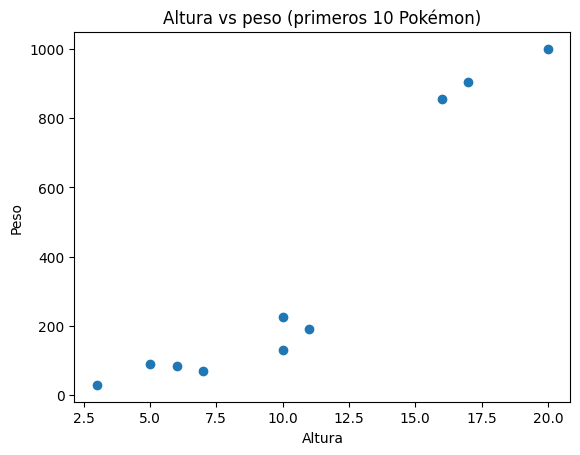

In [46]:
# Relación altura vs peso
plt.scatter(df_poke['height'], df_poke['weight'])
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.title('Altura vs peso (primeros 10 Pokémon)')
plt.show()

### 3.4 Hagamos algo muy chulo

In [47]:
# ! Nueva librería para mostrar imágenes en el notebook
from IPython.display import Image

In [52]:
def get_pokemon(id_number):
    res=requests.get('https://pokeapi.co/api/v2/pokemon/{}'.format(id_number))

    if (res.status_code==200):
        data = res.json()
        return {"id": id_number, 'name':data['name'],'image':data['sprites']['back_default']}

    else:
        raise ValueError("Cannot get pokemon, id does not exist")

def print_pokemon(poke):
    print(str(poke["id"])+" " +poke["name"])
    display(Image(url=poke['image']))

In [13]:
url_5 = "https://pokeapi.co/api/v2/pokemon/5"

In [53]:
get_pokemon(5)

{'id': 5,
 'name': 'charmeleon',
 'image': 'https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/back/5.png'}

In [58]:
# PROBAMOS CON EL POKEMOS CON ID 5
print_pokemon(get_pokemon(5))

5 charmeleon


Sale de espalda, por que asi lo pedimos en el codigo como back_default

In [16]:
for i in range(5):
    print(i)

0
1
2
3
4


In [17]:
for i in range(10):
    print_pokemon(get_pokemon(i + 1))

1 bulbasaur


2 ivysaur


3 venusaur


4 charmander


5 charmeleon


6 charizard


7 squirtle


8 wartortle


9 blastoise


10 caterpie


<h1 style="color: #00BFFF;">🧾 4️⃣ API de Quotes: frases aleatorias</h1>


La API de *Quotes to Scrape* proporciona colecciones de citas organizadas por páginas.  
Es una API sencilla ideal para practicar peticiones HTTP, paginación y extracción de datos en formato JSON.

El endpoint básico para obtener la primera página de citas es:

```python
url = "https://quotes.toscrape.com/api/quotes?page=1"


In [18]:
# URL base de la API
url = "https://quotes.toscrape.com/api/quotes?page=1"

In [19]:
# Hacemos la petición
resp = requests.get(url)
data_quote = resp.json()   # respuesta en JSON

In [20]:
data_quote.keys()

dict_keys(['has_next', 'page', 'quotes', 'tag', 'top_ten_tags'])

In [21]:
len(data_quote['quotes'])

10

In [22]:
data_quote['quotes'][0]

{'author': {'goodreads_link': '/author/show/9810.Albert_Einstein',
  'name': 'Albert Einstein',
  'slug': 'Albert-Einstein'},
 'tags': ['change', 'deep-thoughts', 'thinking', 'world'],
 'text': '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”'}

In [23]:
# Veamos qué devuelve
print(data_quote.keys())
print("Número de citas en esta página:", len(data_quote["quotes"]))

dict_keys(['has_next', 'page', 'quotes', 'tag', 'top_ten_tags'])
Número de citas en esta página: 10


In [24]:
# Convertir a DataFrame
quotes = []
for q in data_quote["quotes"]:
    quotes.append({
        "cita": q["text"],
        "autor": q["author"]["name"],
        "tags": ", ".join(q["tags"])
    })

In [62]:
pd.set_option('display.max_colwidth', None)

In [63]:
df = pd.DataFrame(quotes)
df.head()

,cita,autor,tags
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational"


<h1 style="color: #00BFFF;">😂 5️⃣ API de chistes: un poco de humor programador</h1>

Usaremos la API de **Official Joke** que devuelve chistes generalmente en inglés.

Endpoint:
```text
https://official-joke-api.appspot.com/random_joke
```


In [79]:
url_joke = "https://official-joke-api.appspot.com/random_joke"

response_joke = requests.get(url_joke)
print("Código de estado:", response_joke.status_code)
data_joke = response_joke.json()
data_joke

Código de estado: 200


{'type': 'general',
 'setup': 'What did the Dorito farmer say to the other Dorito farmer?',
 'punchline': 'Cool Ranch!',
 'id': 171}

In [80]:
# Mostrar el chiste de forma legible
setup = data_joke['setup']
punchline = data_joke['punchline']

print("Chiste:")
print(setup)
print("👉", punchline)


Chiste:
What did the Dorito farmer say to the other Dorito farmer?
👉 Cool Ranch!


<img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExYjdmcGs2YnIxMmlzazhqYzlveDFydHE5ZDdkNWo1bWJocHVsdmJ1cyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/Rzd1fC4W3dXvt4LyM3/giphy.gif" width="350px">


### 5.1 Varios chistes en un DataFrame


In [82]:
jokes = []

for i in range(10):
    r = requests.get(url_joke)
    if r.status_code != 200:
        print("Error en la petición", i)
        continue
    d = r.json()
    jokes.append({
        'setup': d['setup'],
        'punchline': d['punchline'],
        'type': d.get('type', None)
    })

df_jokes = pd.DataFrame(jokes)
df_jokes

,setup,punchline,type
0,How do you steal a coat?,You jacket.,general
1,What do you call a cow with no legs?,Ground beef!,general
2,How do you get a baby alien to sleep?,You rocket.,general
3,Why did the melons plan a big wedding?,Because they cantaloupe!,general
4,I started a new business making yachts in my attic this year...,The sails are going through the roof.,general
5,Where do programmers like to hangout?,The Foo Bar.,programming
6,What do ghosts call their true love?,Their ghoul-friend,general
7,Where do you learn to make banana splits?,At sundae school.,general
8,Where do you learn to make banana splits?,At sundae school.,general
9,Did you hear about the two silk worms in a race?,It ended in a tie.,general


<h1 style="color: #00BFFF;">☁️ 6️⃣ OpenWeather: tiempo actual en varias ciudades</h1>

Aquí vas a usar la API de **OpenWeather** para consultar el tiempo en distintas ciudades.

🔴 **Importante:** necesitas una **API key** (gratuita) que se consigue registrándote en su web.
En el código verás `API_KEY = "TU_API_KEY_AQUI"` para que la rellenes.


Se tiene que registrar y poner la API Key

In [67]:
API_KEY = "TU_API_KEY_AQUI"  # pon aquí tu clave real

city = "Madrid"
url_weather = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": city,
    "appid": API_KEY,
    "units": "metric",   # para ºC
    "lang": "es"         # respuestas en español
}

response_weather = requests.get(url_weather, params=params)
print("Código de estado:", response_weather.status_code)
data_weather = response_weather.json()
data_weather


Código de estado: 401


{'cod': 401,
 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}

In [68]:
# Extraer info útil
ciudad = data_weather.get('name')
main = data_weather.get('main', {})
weather_list = data_weather.get('weather', [{}])

temp = main.get('temp')
feels_like = main.get('feels_like')
humidity = main.get('humidity')
description = weather_list[0].get('description')

print(f"Ciudad: {ciudad}")
print(f"Temperatura: {temp} ºC (sensación: {feels_like} ºC)")
print(f"Humedad: {humidity} %")
print(f"Descripción: {description}")


Ciudad: None
Temperatura: None ºC (sensación: None ºC)
Humedad: None %
Descripción: None


### 6.1 Comparar varias ciudades en un DataFrame


In [69]:
cities = ["Madrid", "Barcelona", "Seville", "Paris", "London"]
registros_tiempo = []

for city in cities:
    params["q"] = city
    r = requests.get(url_weather, params=params)
    if r.status_code != 200:
        print("Error con la ciudad:", city)
        continue
    d = r.json()
    main = d.get('main', {})
    weather_list = d.get('weather', [{}])
    registros_tiempo.append({
        "city": d.get('name'),
        "temp": main.get('temp'),
        "feels_like": main.get('feels_like'),
        "humidity": main.get('humidity'),
        "description": weather_list[0].get('description')
    })
    time.sleep(0.3)

df_weather = pd.DataFrame(registros_tiempo)
df_weather


Error con la ciudad: Madrid
Error con la ciudad: Barcelona
Error con la ciudad: Seville
Error con la ciudad: Paris
Error con la ciudad: London


""


In [70]:
# Pequeño gráfico de temperaturas por ciudad
plt.bar(df_weather['city'], df_weather['temp'])
plt.title('Temperaturas por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Temperatura (ºC)')
plt.show()


KeyError: 'city'

---
## 🎓 7️⃣ Conclusiones y ideas para seguir jugando

En este notebook has practicado cómo:

- Hacer peticiones HTTP con `requests` a distintas APIs públicas.
- Leer respuestas en formato JSON y navegar por diccionarios anidados.
- Convertir los datos a **DataFrames** de `pandas`.
- Hacer pequeñas visualizaciones con `matplotlib`.

Algunas ideas para seguir:
- Añadir más campos a los DataFrames (por ejemplo, estadísticas avanzadas de Pokémon).
- Guardar lo que obtienes de las APIs en CSV para analizarlos en otro momento.
- Probar otras APIs públicas (noticias, películas, criptomonedas, etc.).

👉 **Reto final:**
- Elige una de las APIs usadas aquí y crea tu propio análisis o visualización extra.
- Por ejemplo, ordena los Pokémon por peso, o las ciudades por humedad, o analiza autores de quotes.
